In [1]:
import numpy as np
from scipy.optimize import brentq
from scipy import integrate
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dirpath = "./"

## Define frailty classes

In [3]:
class GammaFrailty:
    """ args
            RR: reletive risk (hazard ratio) of prior events
            rate: reletive risk (hazard ratio) of aging per unit of time
            ref_T: period over which hazard ratio is averaged
            latency (< ref_T): the hazard ratio is averaged over [latency, ref_T]
            T: maximal time (in unit) over which risk is updated
            constant: if True, HR is estimated at the moment an event occurred. 
                      in this case, HR is constant over time (applies only to gamma, see Hougaard p.235)
            a : form parameter, alpha, of PVF distributions (a = 0 with gamma, see Hougaard p.241)
            r0: initial risks (per unit of time) for which risks are updated
        values:  a tuple
            [0] a dataframe of updated risks
            [1] a dataframe of parameters [theta0, delta] corresponding to each r0
    """
    def __init__(self, RR, rate, T = 5, a = 0, ref_T = None, r0 = np.arange(1,9)*0.01, 
                 latency = 0, constant = False):
        self.RR = RR
        self.rate = rate
        if not ref_T:
            ref_T = T
        self.ref_T = ref_T
        self.r0 = r0
        self.tau = np.arange(T+1)        
        self.constant = constant
        self.latency = latency
        self.a = a
        
    def calc_lambda_ratio(self, p0, delta):  # returns lambda0/(log(rate)*thata0) given an inital risk p0 (used only to compute risk updates)
        y = -np.log(1-p0)/delta
        r = (np.exp(y)-1)/(self.rate - 1) 
        return r
    
    def calc_h0(self, p0, theta_0, delta):   # returns h0 = lambda0/log(rate) 
        r = self.calc_lambda_ratio(p0, delta)
        lambda_0 = theta_0*r
        return lambda_0
    
    def calc_A(self, lambda_0, t):           # returns culumative hazard A[t] up to time t
        At = (self.rate**t - 1)*lambda_0
        return At

    # returns pointwise HR[t] of failure/non-failure at time t in the population with initial risk p0
    def interval_average(self, t, lambda_0, theta_0, delta, lt_end):

        At = self.calc_A(lambda_0, t)
            #   averaged over accumulated failures up to time t
            #   The weight at time s in [0,t] is the prob density of failure at s given t,  
            #   which is -dS[s,t]/ds = S[s,t]*lambda[s|T>t]  (Hougaard p.235, (7.38)) 
        def weight(s):
            As = self.calc_A(lambda_0, s)
            w = self.rate**s / (theta_0 + As + At)**(delta + 1)  # As it is a weight, constant factors are dropped
            return w
        def integrand(s):   # log HR at time t of failure at time s compared to non-failure
            As = self.calc_A(lambda_0, s)
            lnhr = np.log(1 + 1/delta) + np.log(theta_0 + 2*At) - np.log(theta_0 + As + At)
            lnhr *= weight(s)
            return lnhr

        lnHR_t = integrate.quad(integrand, lt_end, t)[0]
        lnHR_t /= integrate.quad(weight, lt_end, t)[0]

        return lnHR_t    
    
    # returns HR of failure/non-failure averaged over [0, t_ref] in the population with initial risk p0        
    def calc_lnHR(self, t_ref, theta_0, delta, p0, latency):  
        
        lambda_0 = self.calc_h0(p0, theta_0, delta) 
        lt_end = 0 + latency
            
        def weight_t(t):    #   The weight at time t is the survival at time t,
            At = self.calc_A(lambda_0, t)
            w = 1/(theta_0 + At)**delta
            return w
        
        def interval_average(t):
            lnHR_t = self.interval_average(t, lambda_0, theta_0, delta, lt_end)
            lnHR_t *= weight_t(t)            
            return lnHR_t
    
        lnHR = integrate.quad(interval_average, lt_end, t_ref)[0] /integrate.quad(weight_t, lt_end, t_ref)[0]  
        
        return lnHR
    
    # given p0, returns risk over the next year of a person who has been event-free    
    def calc_risk(self, p0, theta_0, delta): 
        
        r = self.calc_lambda_ratio(p0, delta)
        enum  = 1 + (self.rate**(self.tau) - 1)*r
        denom = 1 + (self.rate**(self.tau + 1) - 1)*r
        p = 1 - (enum/denom)**delta
           
        return p
        
    def calc_avHR(self, p0, theta_0, delta):
        t = self.tau + 1        
        lambda_0 = self.calc_h0(p0, theta_0, delta) 
        lnhr = list( map(lambda y: self.interval_average(y, lambda_0, theta_0, delta, 0), t))
        return np.exp(lnhr)

    
    def find_theta_0(self, p0):
                    
        def dif_lnhr(theta_0):                
            delta = theta_0**(1 - self.a)                
            ref_lnHR = self.calc_lnHR(self.ref_T, theta_0, delta, p0, self.latency)           
            return ref_lnHR - np.log(self.RR) 
        
        theta_0 = brentq(dif_lnhr, 0.02, 10)
        
        delta = theta_0**(1 - self.a)
            
        return theta_0, delta
    
    def predict(self):
        
        res = pd.DataFrame(columns = self.r0)
        params = []
        
        for p0 in self.r0:
            
            if self.constant and self.a == 0:
                theta_0 = 1 /(self.RR - 1) 
                delta = theta_0
            else:
                theta_0, delta = self.find_theta_0(p0) 
            res_k = self.calc_risk(p0, theta_0, delta)
            res.loc[:, p0] = res_k
            params.append([theta_0, delta])
            
        params = pd.DataFrame(params)
        params.columns = ["theta_0", "delta"]
        params.index = self.r0
        return [res, params]


In [4]:
class PVFFrailty(GammaFrailty):
    
    """ 
    a = 0.5 corresponds to inverse gaussian 
    a < 0 corresponds to compound poisson 
    """
    def __init__(self, RR, rate, T = 5, a = 0.5, ref_T = None, r0 = np.arange(1,9)*0.01, latency = 0):
        super().__init__(RR = RR, rate = rate, T = T, a = a, ref_T = ref_T, r0 = r0, latency = latency)
        
    def calc_h0(self, p0, theta_0, delta):     # returns h0 = lambda0/log(rate)        
        y = - self.a * np.log(1 - p0)/delta + theta_0**self.a      
        y =  y**(1/self.a) - theta_0
        y /= self.rate - 1        
        return y
    
    def calc_S(self, theta_1, theta_2, delta):  # returns survival (see Hougaard p.505, (A.17))
        b = theta_2**self.a - theta_1**self.a
        S = np.exp( - delta * b /self.a ) 
        return S

    def interval_average(self, t, lambda_0, theta_0, delta, lt_end): 

        At = self.calc_A(lambda_0, t) 

        def weight(s):                       # see Hougaard p.505, (A.18)
            As = self.calc_A(lambda_0, s)   
            theta_s = theta_0 + As + At
            S = self.calc_S(theta_0, theta_s, delta)
            w = S * self.rate**s * theta_s**(self.a - 1)  # As it is a weight, constant factors are dropped
            return w

        def integrand(s):   # see Hougaard p.244 (7.60)
            As = self.calc_A(lambda_0, s)
            At = self.calc_A(lambda_0, t)
            c = theta_0 + As + At
            y = (1 - self.a) * c**(-self.a) + self.a
            lnhr = np.log(y) - np.log(delta)
            lnhr *= weight(s)
            return lnhr

        lnHR_t = integrate.quad(integrand, lt_end, t)[0]
        lnHR_t /= integrate.quad(weight, lt_end, t)[0]

        return lnHR_t    
    
    def calc_lnHR(self, t_ref, theta_0, delta, p0, latency):
        
        lambda_0 = self.calc_h0(p0, theta_0, delta) 
        lt_end = 0 + latency
        
        def weight_t(t):
            At = self.calc_A(lambda_0, t)
            w = self.calc_S(theta_0, theta_0 + At, delta)
            return w

        def interval_average(t):

            lnHR_t = self.interval_average(t, lambda_0, theta_0, delta, lt_end)
            lnHR_t *= weight_t(t)
            
            return lnHR_t
       
        lnHR  = integrate.quad(interval_average, lt_end, t_ref)[0] 
        lnHR /= integrate.quad(weight_t, lt_end, t_ref)[0]         
        return lnHR        
        
    def calc_risk(self, p0, theta_0, delta):
        lambda_0 = self.calc_h0(p0, theta_0, delta)
        theta_1  = theta_0 + self.calc_A(lambda_0, self.tau)
        theta_2  = theta_0 + self.calc_A(lambda_0, self.tau + 1)
        S = list( map(lambda x, y: self.calc_S(x, y, delta), theta_1, theta_2) )
        p = 1 - np.array(S) 
        return p 

### Mapping 

In [5]:
def get_index(Tprev, df, targets = np.arange(0.005, 0.041, 0.005) ):
    """
    find intersections between risk trajectories and target risks 
    """
    import math    
    def bracket_integer(k):
        m = math.floor(k)
        n = math.ceil(k)
        return m, n
    if Tprev % 1 == 0:
        nearest_idx = [ (df.loc[Tprev,:] - t).abs().idxmin() for t in targets ]
    else:
        m, n = bracket_integer(Tprev)
        rho = np.array([n-Tprev, Tprev-m])
        av =  rho[0]*df.loc[m,:] + rho[1]*df.loc[m,:] 
        nearest_idx = [ (av - t).abs().idxmin() for t in targets ]
    return nearest_idx

In [6]:
# hazard-risk converiosn 
def lambda_to_p(lambda_0, r, theta_0, delta, alpha = 0, frailty = "gamma"):
    A_1 = lambda_0*(r-1)/np.log(r)
    if frailty == "gamma":
        S_1 = theta_0**delta /(theta_0 + A_1)**delta
    else:
        S_1 = np.exp( -(delta/alpha)*( (theta_0 + A_1)**alpha - theta_0**alpha ) )
    return 1 - S_1

def p_to_lambda(p_0, r, theta_0, delta, alpha = 0, frailty = "gamma"):
    if frailty == "gamma":
        lambda_0 = ( (1 - p_0)**(-1/delta) - 1) * theta_0 * np.log(r)/(r-1)
    else:
        y = -(alpha/delta)*np.log(1-p_0) + theta_0**alpha
        y = y**(1/alpha)
        lambda_0 = np.log(r)*(y-theta_0)/(r-1)
    return lambda_0

In [7]:
def map_risks(RR, rate, Tobs, latencies, r0, frailty = "gamma"):      
    preds = []
    for latency in latencies:
        if frailty == "gamma":
            alpha = 0
            mod = GammaFrailty(  RR = RR, rate = rate, T = latency, a = alpha, ref_T = latency + Tobs, r0 = r0,   # gamma
                                 latency = latency, constant = False)
        elif frailty == "invG":
            alpha = 0.5
            mod = PVFFrailty(RR = RR, rate = rate, T = latency, a = alpha, ref_T = latency + Tobs, r0 = r0,       # invG
                             latency = latency)  
            
        pred, params = mod.predict()
        adj_pred = pred.copy()
        idx = get_index(latency, pred, targets = np.arange(0.005, 0.041, 0.005)) # find intersection
        theta_0 = params.loc[idx, "theta_0"].values  
        delta = params.loc[idx, "delta"].values    
        pred = pred.loc[:, idx]                                               
        for i in pred.index:
            p = pred.values[i, :]
            lam = p_to_lambda(p, rate, theta_0, delta, alpha, frailty)         # convert to hazard
            adj_lam = lam * rate**(latency - i)                                # allign attained age
            adj_p = lambda_to_p(adj_lam, rate, theta_0, delta, alpha, frailty) # convert to annual risk
            pred.loc[i, :] = adj_p.copy() 
        preds.append(pred)        
    return preds  

In [8]:
def plot_4( ys, RRs, RRa, alpha, Tobs, latencies, frailty = "gamma"):
    n_pred = ys[0].shape[1]
    T = max(latencies)
    tau = T + 1 if T else ys[0].shape[0]
    x = np.arange(tau)
    fig, axes= plt.subplots(1, 4, figsize = (34, 7))
    plt.subplots_adjust(wspace= 0.25, hspace = 0.25)   
    i = 0
    for col in range(4):  
        if i < len(ys):
            if col == 0:
                axes[col].set_ylabel("Stroke risk (/year)", size = 22, labelpad = 10)
            else:
                axes[col].set_ylabel("", size = 1)
            axes[col].set_xticks(x)
            axes[col].set_xlabel("Time since AF diagnosis (year)", size = 22, labelpad = 10)
            axes[col].set_ylim([0, 0.072])
            axes[col].set_xlim([0, T + .15])
            axes[col].tick_params(axis = 'x', labelsize = 18)
            axes[col].tick_params(axis = 'y', labelsize = 18)
            axes[col].grid(True, which="both", axis="y")
        else:
            axes[col].set_xticks([])
            axes[col].set_yticks([])
            axes[col].set_xlabel("", size = 1)
            for edge in ('right', 'top', 'bottom', 'left'):
                axes[col].spines[edge].set_visible(False)
        i += 1
    j = 0
    for RR in RRs: 
        for lat in latencies: 
            y = ys[j]
            end = int(lat) + 1 
            axes[j].set_title(f"Cohort entry at year {lat}", size = 24, pad = 12)
            axes[j].axvline(x = lat, color = "maroon") 
            for k in range(n_pred):
                sns.lineplot(x = x[:end], y = y.iloc[:end, k], ax = axes[j], linewidth=2, color = "steelblue", zorder = 3)  
            j += 1
    plt.show()
    path = f"aging_{RRa:.1f}_{frailty}"
    fig.savefig(dirpath + path + ".tiff", bbox_inches='tight', pad_inches=0.1)

In [9]:
Tobs = 2 
HRs_prior_stroke = (2.1, 3.6)
r0 = 0.0001*np.arange(1, 1001) 
latencies = (1, 3)
aging_per_decade = (1.3, 1.7)
frailties = ("gamma", "invG")

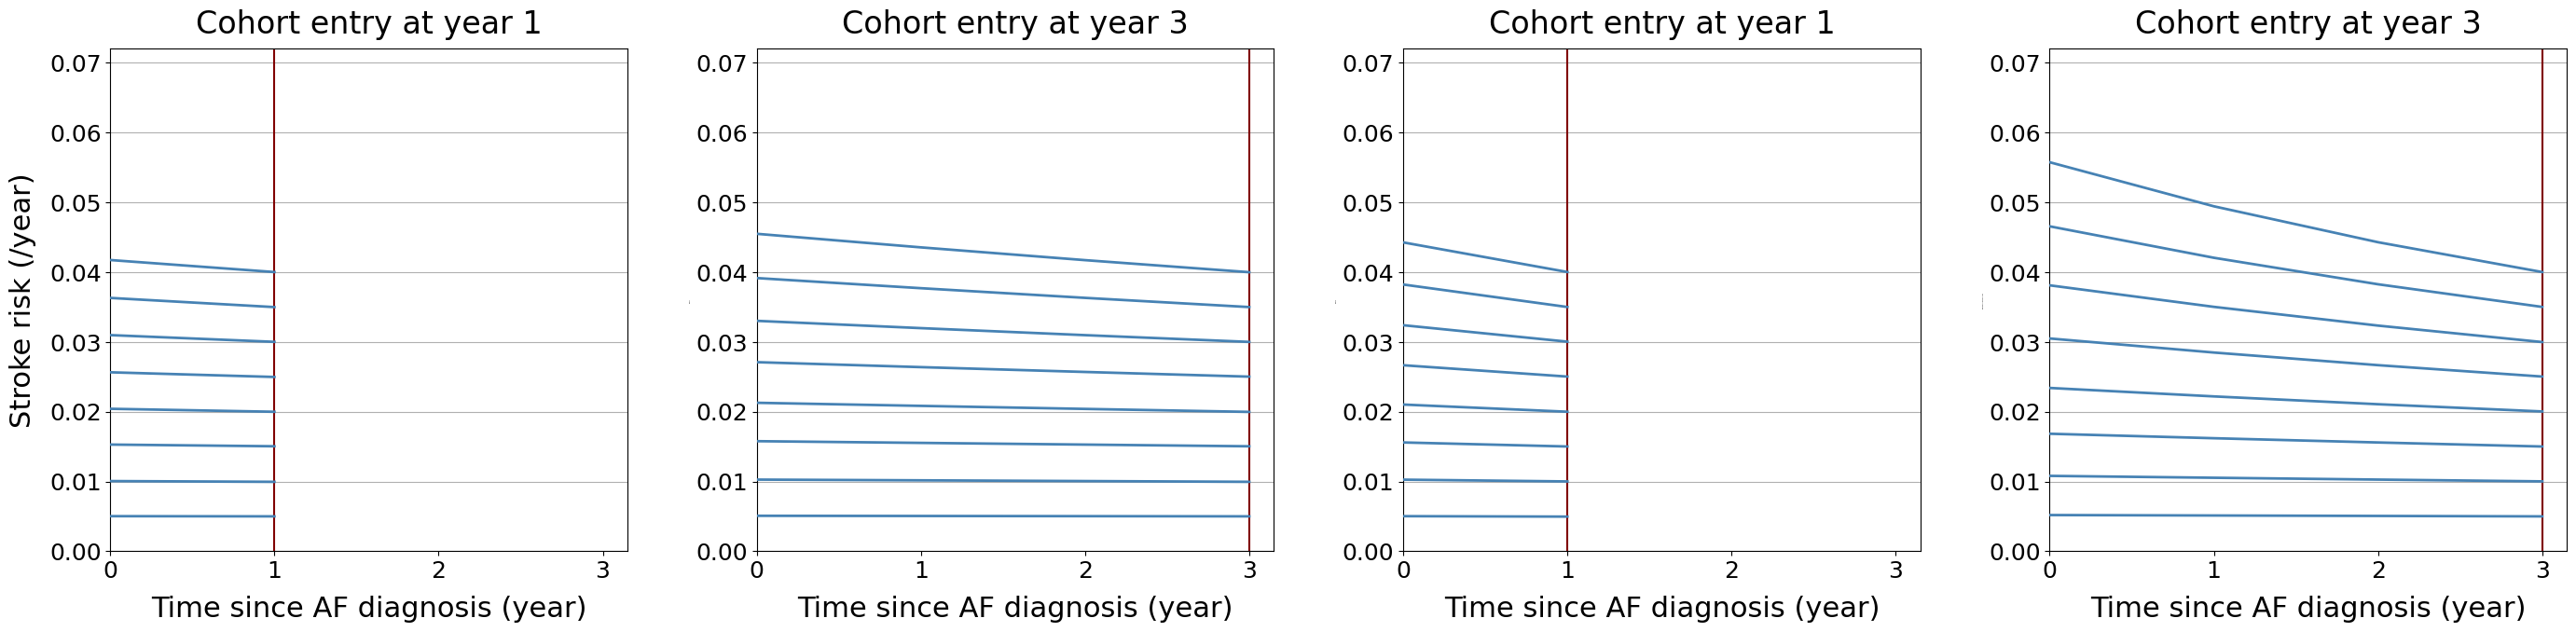

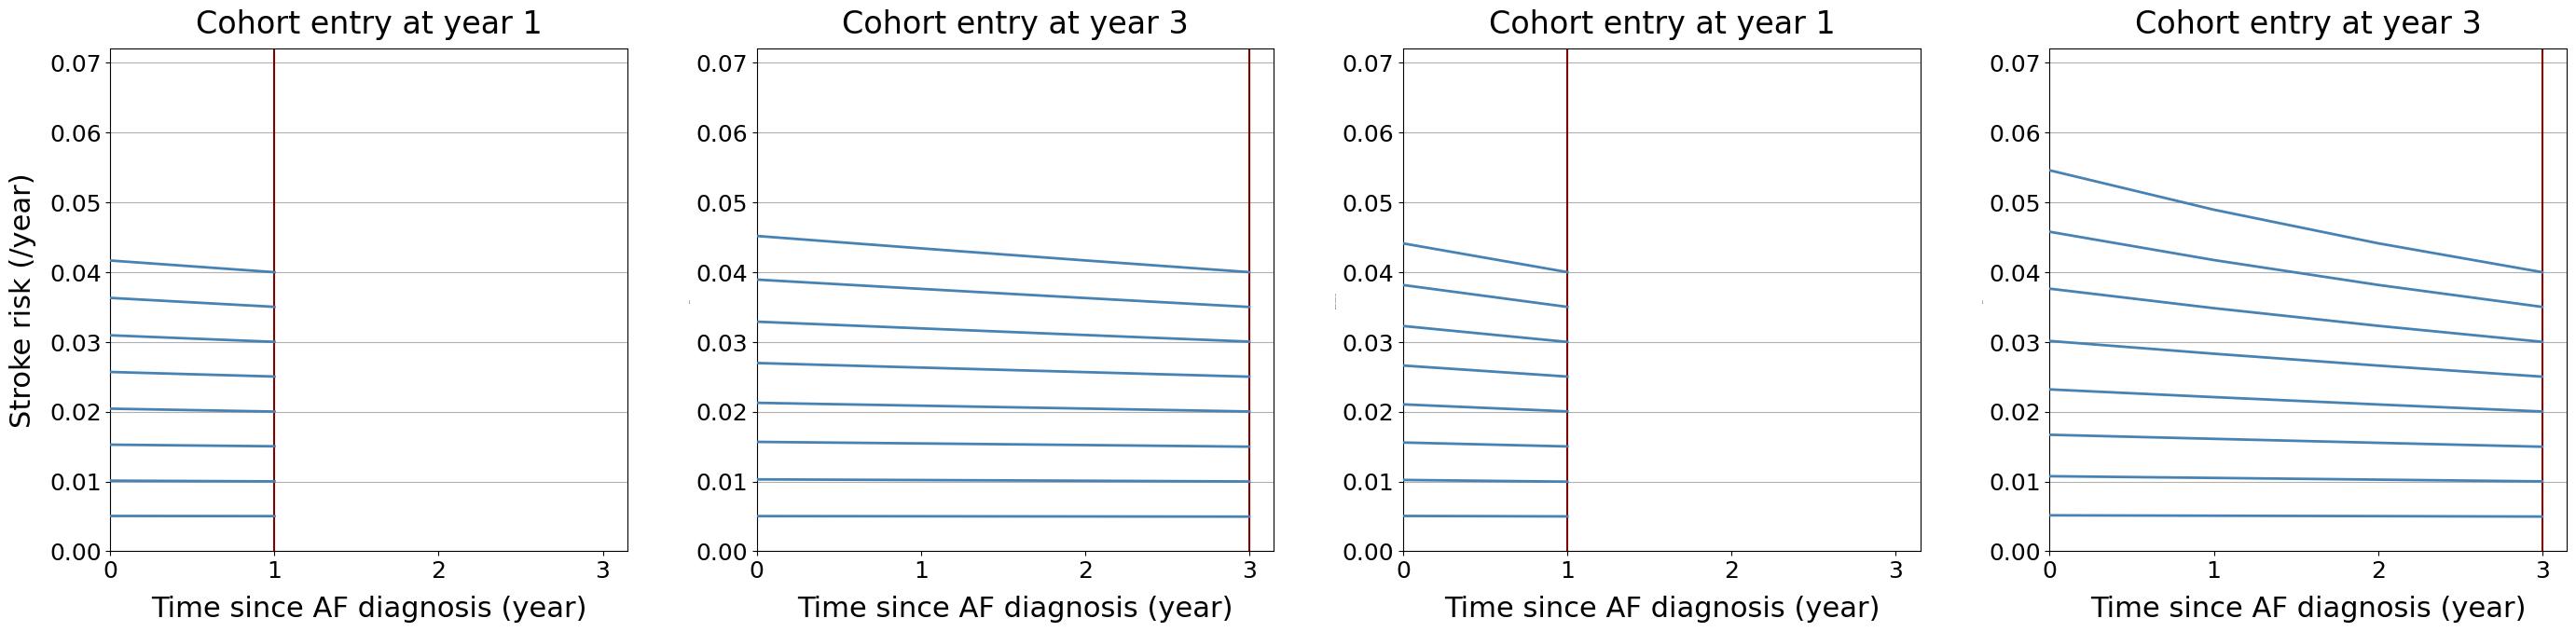

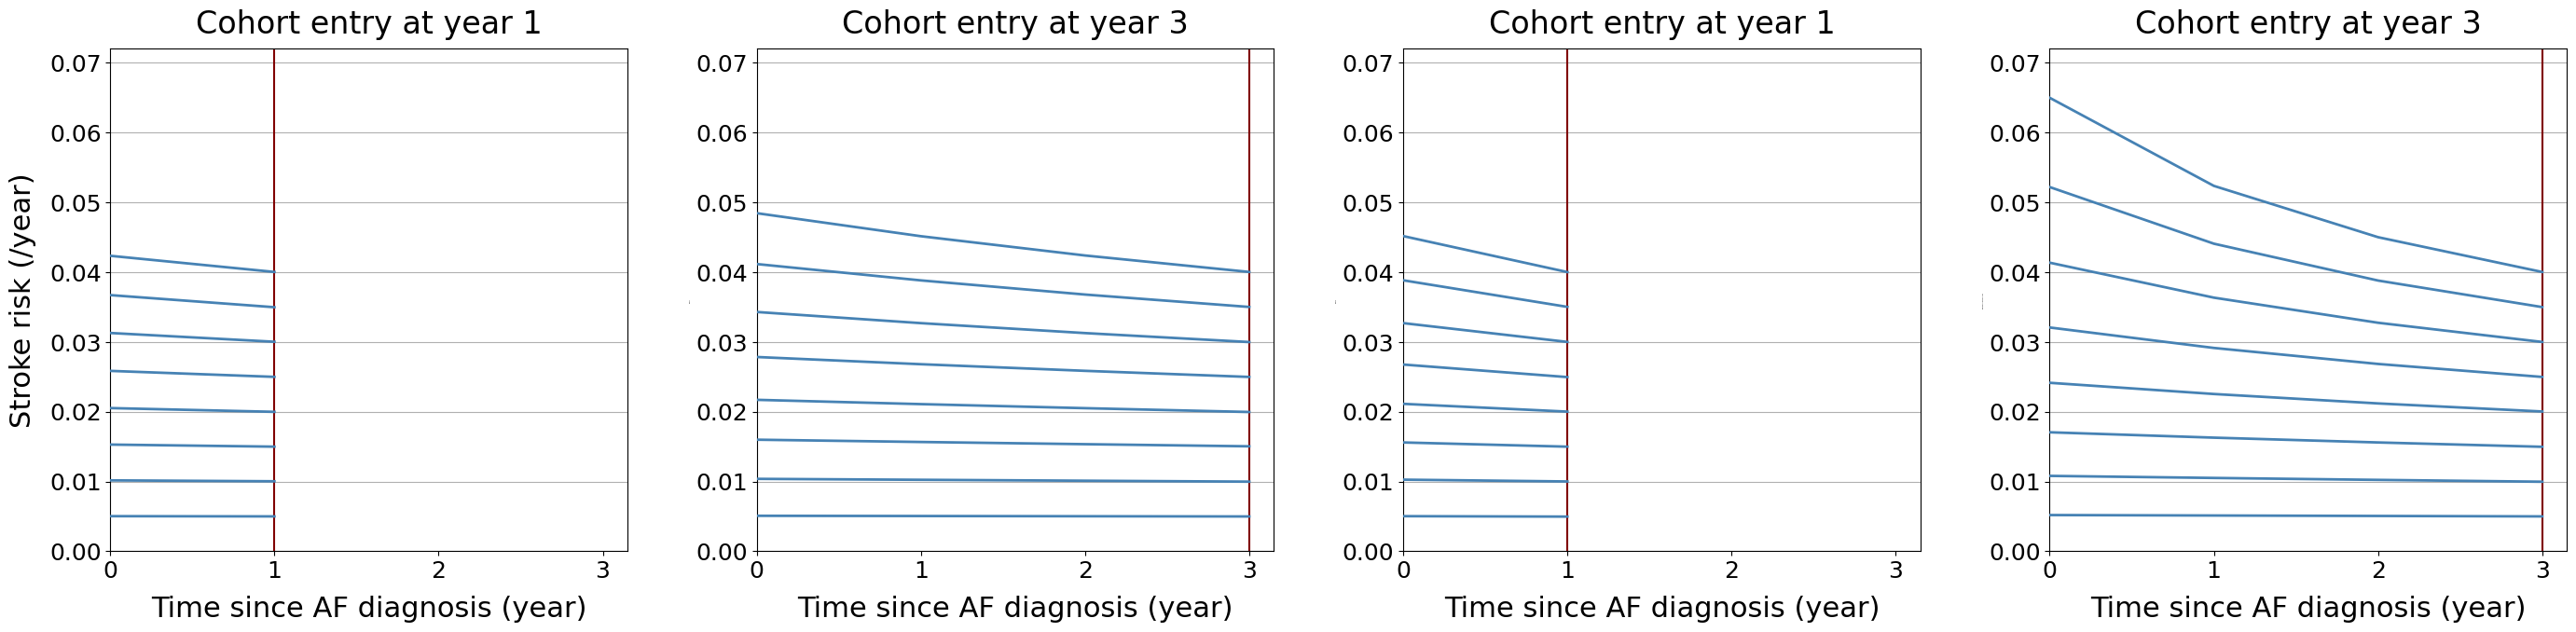

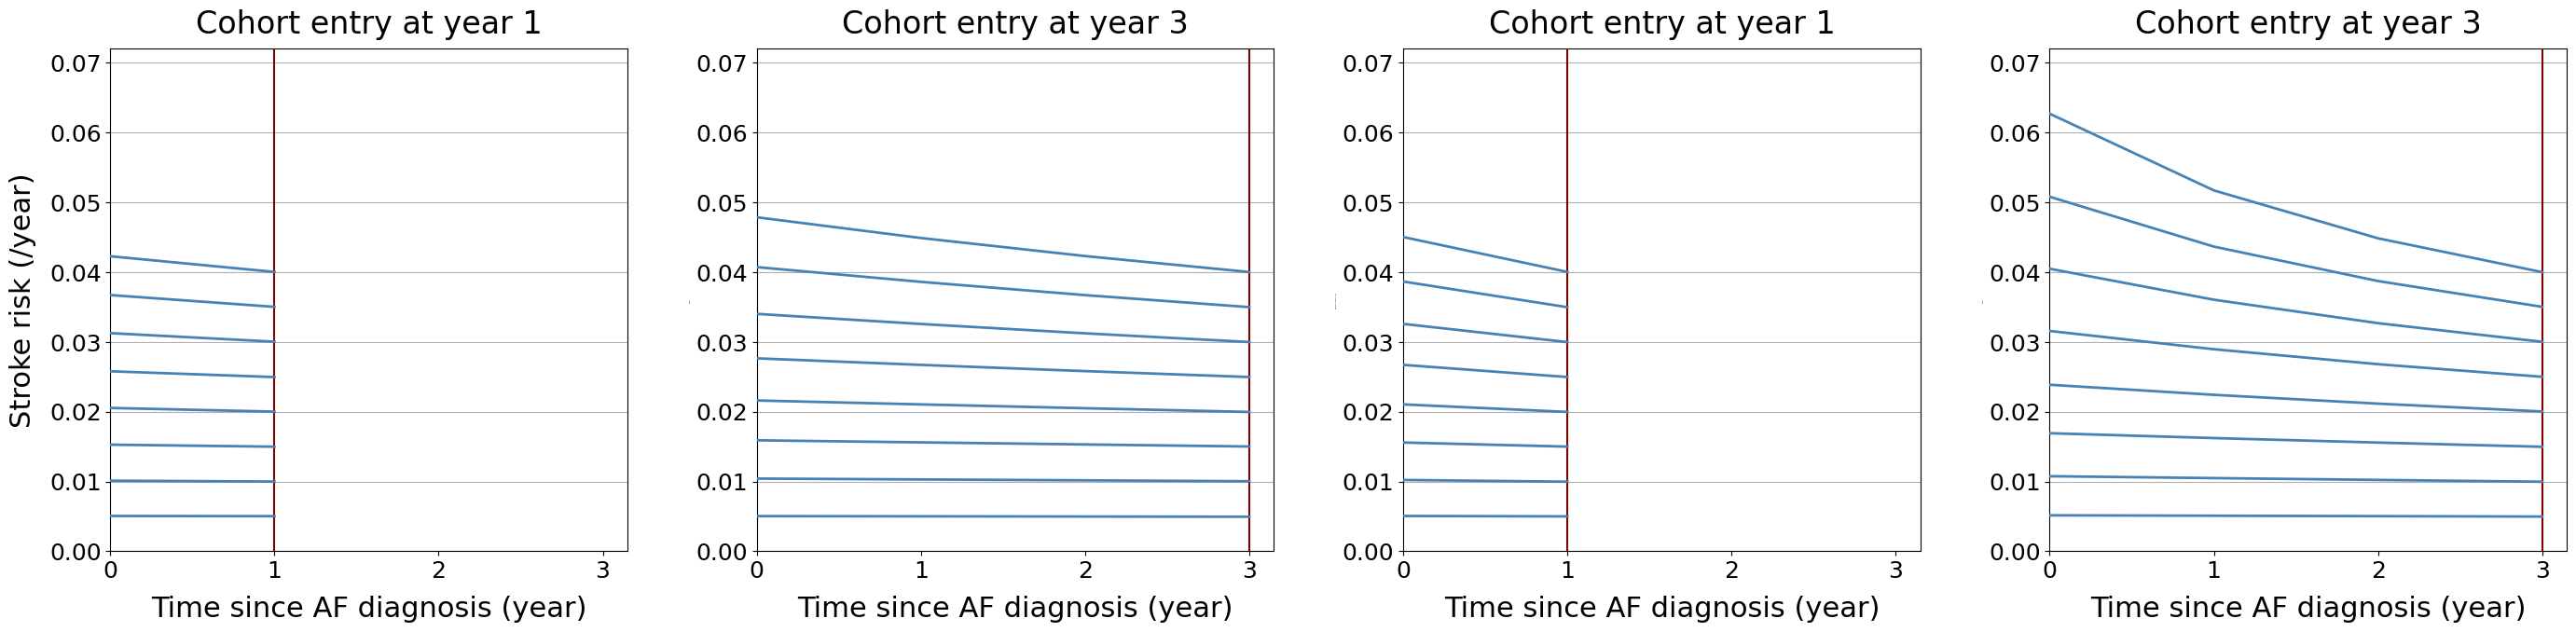

In [10]:
for frailty in frailties:
    for aging in aging_per_decade:
        rate = aging**0.1
        ys = []
        for HR in HRs_prior_stroke:
            preds = map_risks(HR, rate, Tobs, latencies, r0, frailty)    
            ys += preds
        plot_4( ys, HRs_prior_stroke, aging, rate, Tobs, latencies, frailty)      

### Integrate into a figure

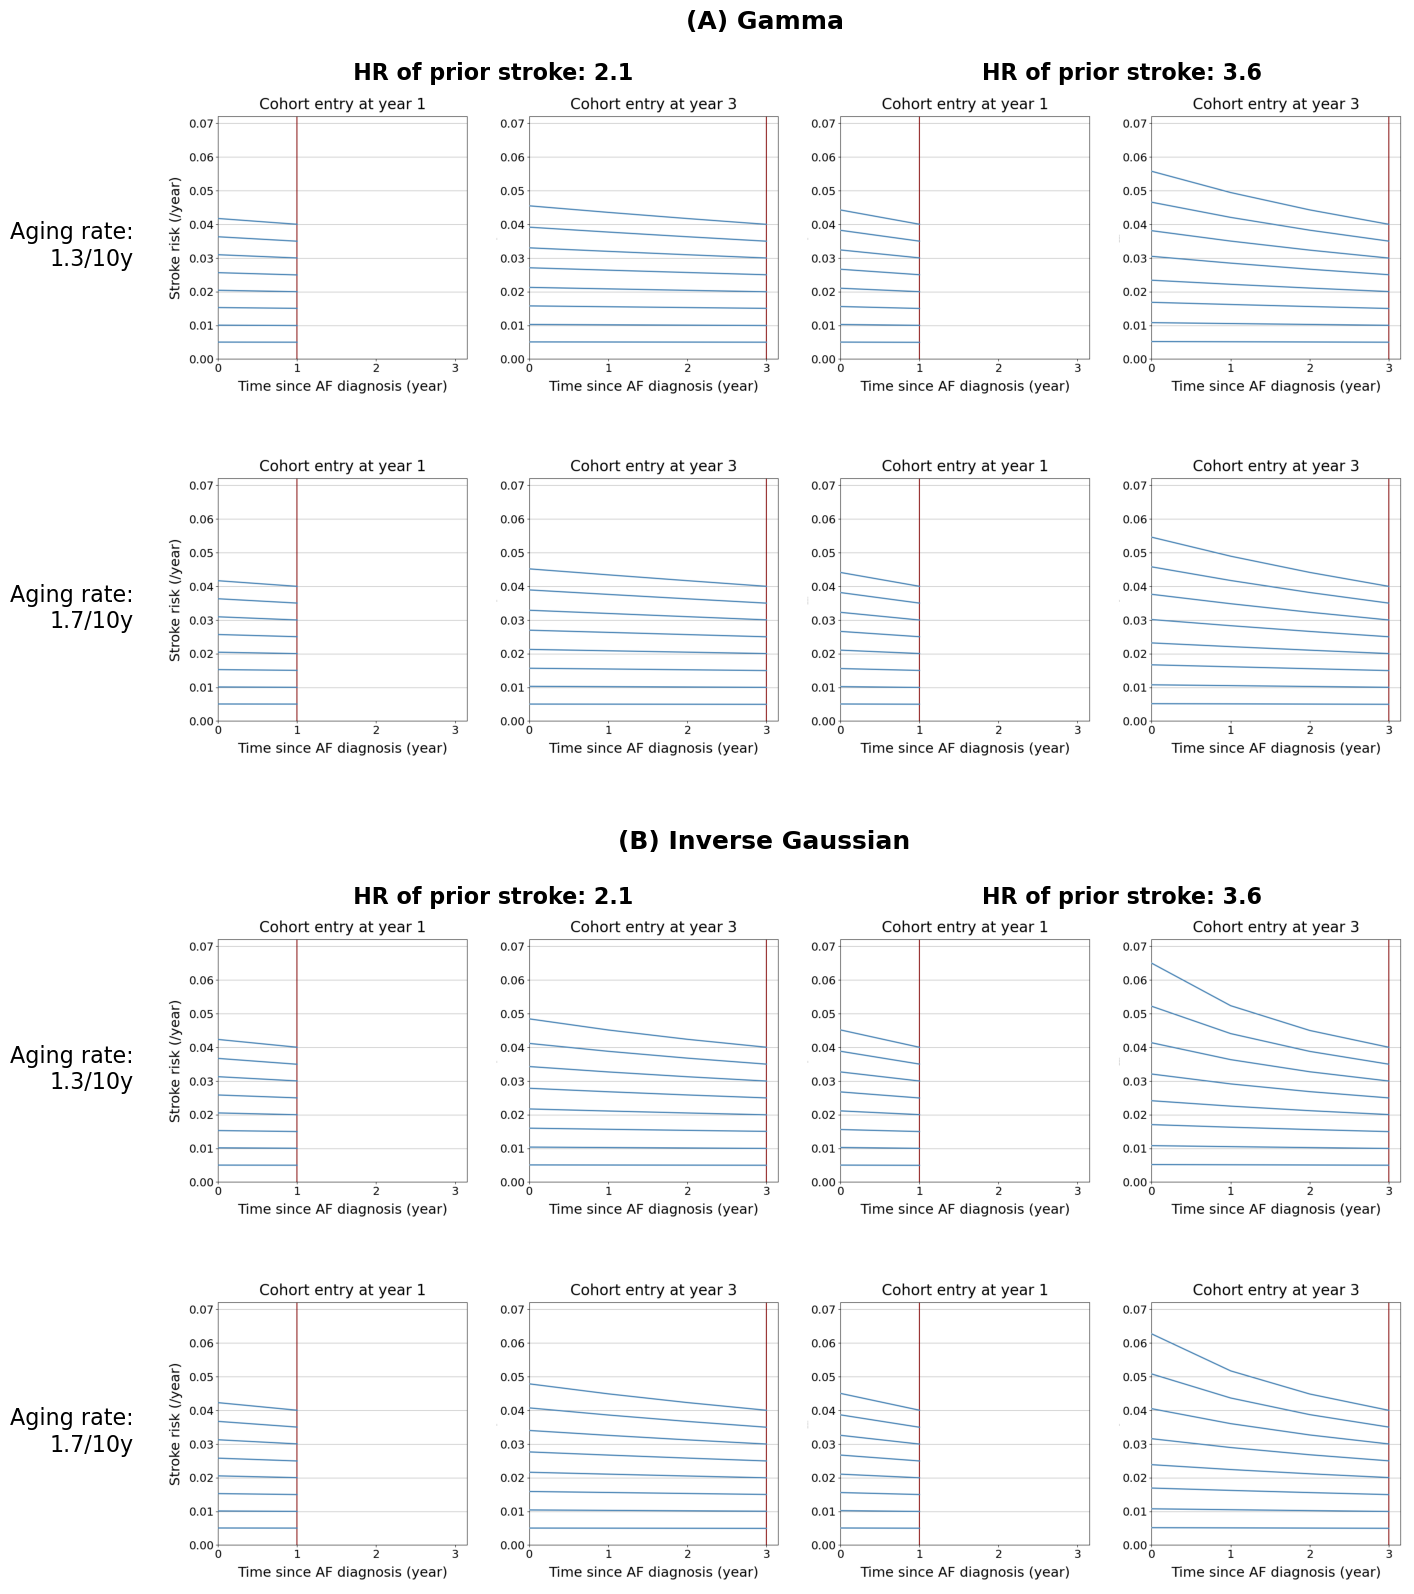

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

def create_combined_figure():
    img_gamma_13 = Image.open('aging_1.3_gamma.tiff')
    img_gamma_17 = Image.open('aging_1.7_gamma.tiff')
    img_invg_13 = Image.open('aging_1.3_invG.tiff')
    img_invg_17 = Image.open('aging_1.7_invG.tiff')

    fig = plt.figure(figsize=(16, 20), constrained_layout=False)
    
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.15)

    def plot_section(grid_pos, img_top, img_bottom, title):
        sub_gs = gs[grid_pos].subgridspec(2, 1, hspace=0.025)
        fig.text(0.5, 0.9 - (grid_pos * 0.41), title, ha='center', fontsize=18, fontweight='bold')
        ax1 = fig.add_subplot(sub_gs[0])
        ax1.imshow(img_top)
        ax1.axis('off')
        ax1.text(-0.025, 0.5, "Aging rate:\n1.3/10y", transform=ax1.transAxes, 
                 ha='right', va='center', fontsize=16)
        ax1.set_title("                   HR of prior stroke: 2.1                                             HR of prior stroke: 3.6             ", fontsize=16, pad = 10, fontweight='bold')
        ax2 = fig.add_subplot(sub_gs[1])
        ax2.imshow(img_bottom)
        ax2.axis('off')
        ax2.text(-0.025, 0.5, "Aging rate:\n1.7/10y", transform=ax2.transAxes, 
                 ha='right', va='center', fontsize=16)

    plot_section(0, img_gamma_13, img_gamma_17, "(A) Gamma")
    plot_section(1, img_invg_13, img_invg_17, "(B) Inverse Gaussian")

    plt.savefig('Combined_Figure_1.png', bbox_inches='tight', dpi=300)
    plt.show()

if __name__ == "__main__":
    create_combined_figure()